This notebook contains comparisons, convergence tests and benchmark runs between the new simulator in rust and the original CasADi one.
It also demonstrates how to use the simulators.

In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

import manywells.simulator as sim
import manywells_rs as sim_rs

from scripts.compare_simulators import run_convergence, plot_convergence, run_benchmark, compare_operating_point
from scripts.plot_simulator import plot_residual, plot_solution
from scripts.load_well_from_dataset import load_well_config

%load_ext autoreload
%autoreload 2

I downloaded the dataset locally to ease the development process. [Download the manywells datasets](https://huggingface.co/datasets/solution-seeker-as/manywells) and store them under `data/`.

In [2]:
dataset_name_sol = "manywells-sol"

df_sol = pd.read_csv(f"data/{dataset_name_sol}/{dataset_name_sol}-1.zip", compression="zip")
config_sol = pd.read_csv(f"data/{dataset_name_sol}/{dataset_name_sol}-1_config.zip", compression="zip")

dataset_name_nsol = "manywells-nsol"

df_nsol = pd.read_csv(f"data/{dataset_name_nsol}/{dataset_name_nsol}-1.zip", compression="zip")
config_nsol = pd.read_csv(f"data/{dataset_name_nsol}/{dataset_name_nsol}-1_config.zip", compression="zip")


# Recreate histograms from figure 8 in paper, and compare against dataset generated by new simulator


In [3]:
def compare_distributions(df_old, df_new, filename=None):
    import matplotlib.pyplot as plt

    plt.clf()
    fig, axs = plt.subplots(3, 3, figsize=(16, 8))
    fig.delaxes(axs[2, 2])
    
    (df_old['CHK']*100).hist(alpha=0.5, density=True, bins=25, ax=axs[0,0], label="old")
    (df_new['CHK']*100).hist(alpha=0.5, density=True, bins=25, ax=axs[0,0], label="rs")
    axs[0, 0].set(xlabel="CHK (%)", ylabel="density")
    
    df_old['QGL'].hist(alpha=0.5, density=True, bins=25, ax = axs[0, 1], label="old")
    df_new['QGL'].hist(alpha=0.5, density=True, bins=25, ax = axs[0, 1], label="rs")
    axs[0, 1].set(xlabel="QGL (Sm3/h)", ylabel="density")
    
    df_old['FGAS'].hist(alpha=0.5, density=True, bins=25, ax = axs[0, 2], label="old")
    df_new['FGAS'].hist(alpha=0.5, density=True, bins=25, ax = axs[0, 2], label="rs")
    axs[0, 2].set(xlabel="FGAS (-)", ylabel="density")
    
    df_old['FOIL'].hist(alpha=0.5, density=True, bins=25, ax = axs[1, 0], label="old")
    df_new['FOIL'].hist(alpha=0.5, density=True, bins=25, ax = axs[1, 0], label="rs")
    axs[1, 0].set(xlabel="FOIL (-)", ylabel="density")
    
    df_old['PWH'].hist(alpha=0.5, density=True, bins=25, ax = axs[1,1], label="old")
    df_new['PWH'].hist(alpha=0.5, density=True, bins=25, ax = axs[1,1], label="rs")
    axs[1, 1].set(xlabel = "PWH (bar)", ylabel="density")
    
    df_old['PDC'].hist(alpha=0.5, density=True, bins=25, ax = axs[1,2], label="old")
    df_new['PDC'].hist(alpha=0.5, density=True, bins=25, ax = axs[1,2], label="rs")
    axs[1, 2].set(xlabel = "PDC  (bar)", ylabel="density")
    
    df_old['TWH'].hist(alpha=0.5, density=True, bins=25, ax = axs[2, 0], label="old")
    df_new['TWH'].hist(alpha=0.5, density=True, bins=25, ax = axs[2, 0], label="rs")
    axs[2, 0].set(xlabel = "TWH (K)", ylabel="density")
    
    df_old['QTOT'].hist(alpha=0.5, density=True, bins=25, ax = axs[2, 1], label="old")
    df_new['QTOT'].hist(alpha=0.5, density=True, bins=25, ax = axs[2, 1], label="rs")
    axs[2, 1].set(xlabel = "QTOT (Sm3/h)", ylabel="density")
    
    for i in range(3):
        for j in range(3):
            if (i, j) != (2, 2):
                axs[i, j].legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2)
    
    fig.tight_layout()
    if filename:
        plt.savefig(f"{filename}.svg")
    
    plt.show()


First, this is generated with the `scripts/data_generation/open_loop_stationary/generate_well_data_rust_simulator.py` script.

In [4]:
dataset_name_sol_rs = "manywells-sol_rs"
df_sol_rs = pd.read_csv(f"data/{dataset_name_sol_rs}/{dataset_name_sol_rs}-1.csv")
config_sol_rs = pd.read_csv(f"data/{dataset_name_sol_rs}/{dataset_name_sol_rs}-1_config.csv")

<Figure size 640x480 with 0 Axes>

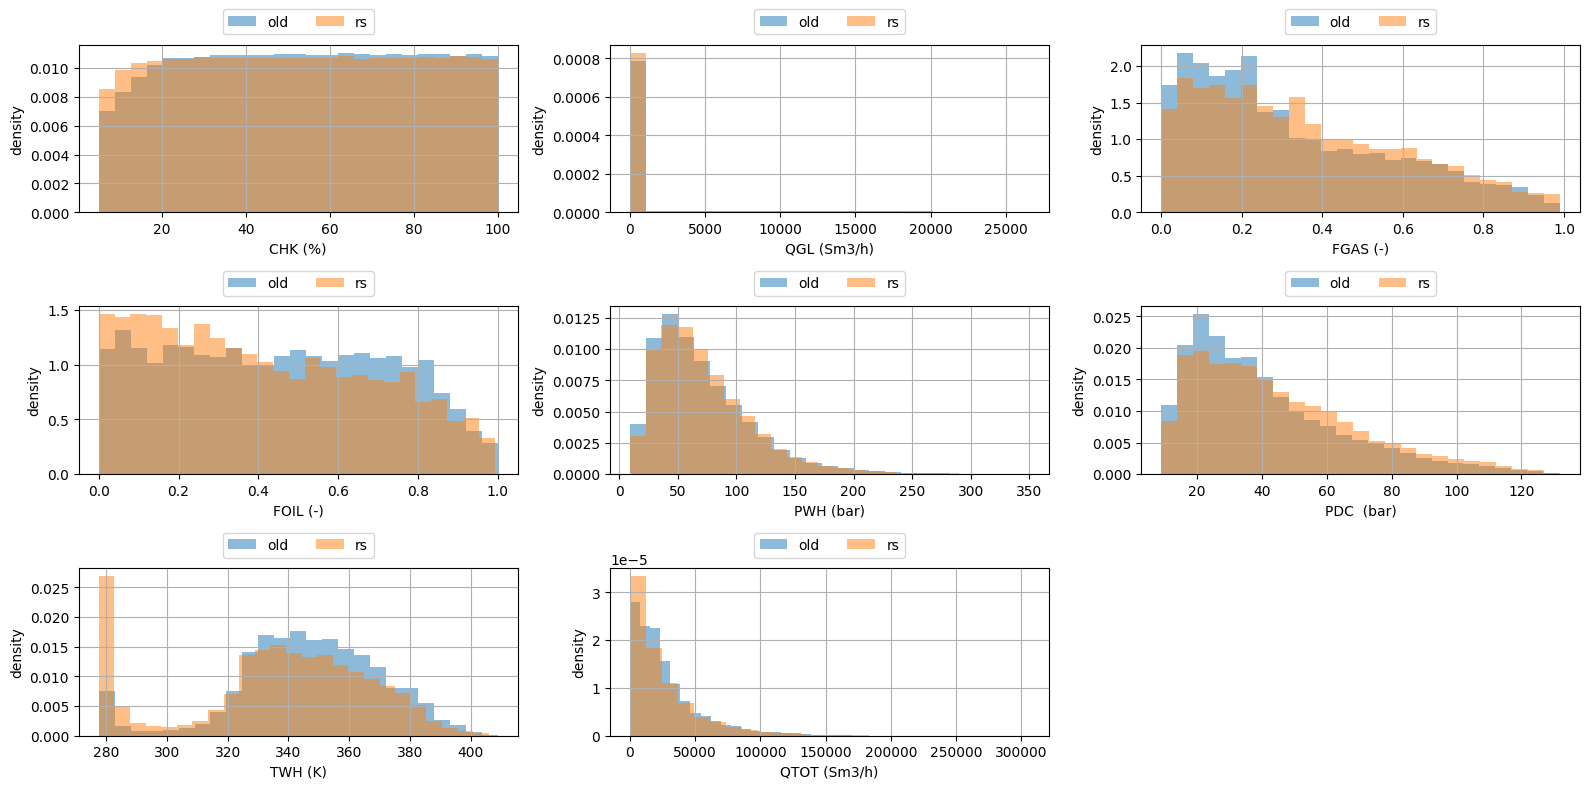

In [5]:
# overall comparison (all solutions that were found, including 2 solutions on one well config if solver found this)
compare_distributions(df_sol, df_sol_rs)

In [6]:
df_sol_rs_lowest = df_sol_rs[df_sol_rs['solution_number'] == 0] # lower pbh

idx = df_sol_rs.groupby(['ID', 'sample_id'])['solution_number'].idxmax()
df_sol_rs_highest = df_sol_rs.loc[idx] # max solution number. this gives only the highest pbh solution found (and includes those were only 1 sol were found)


# groups where more than one solution exists
grp = df_sol_rs.groupby(['ID', 'sample_id'])['solution_number']
counts = grp.transform('size')

df_multi = df_sol_rs[counts > 1]

idx_low = df_multi.groupby(['ID', 'sample_id'])['solution_number'].idxmin()
df_sol_rs_lowest_if_2 = df_multi.loc[idx_low]  # lowest pbh, only when >=2 solutions


df_sol_rs_highest_if_2 = df_sol_rs[df_sol_rs['solution_number'] == 1] # higher pbh (but might be problematic if only 1 sol were found)


---------------- sol -------------------
lowest: if 1 sol, then include it. if 2 sol, take solution_number 0


<Figure size 640x480 with 0 Axes>

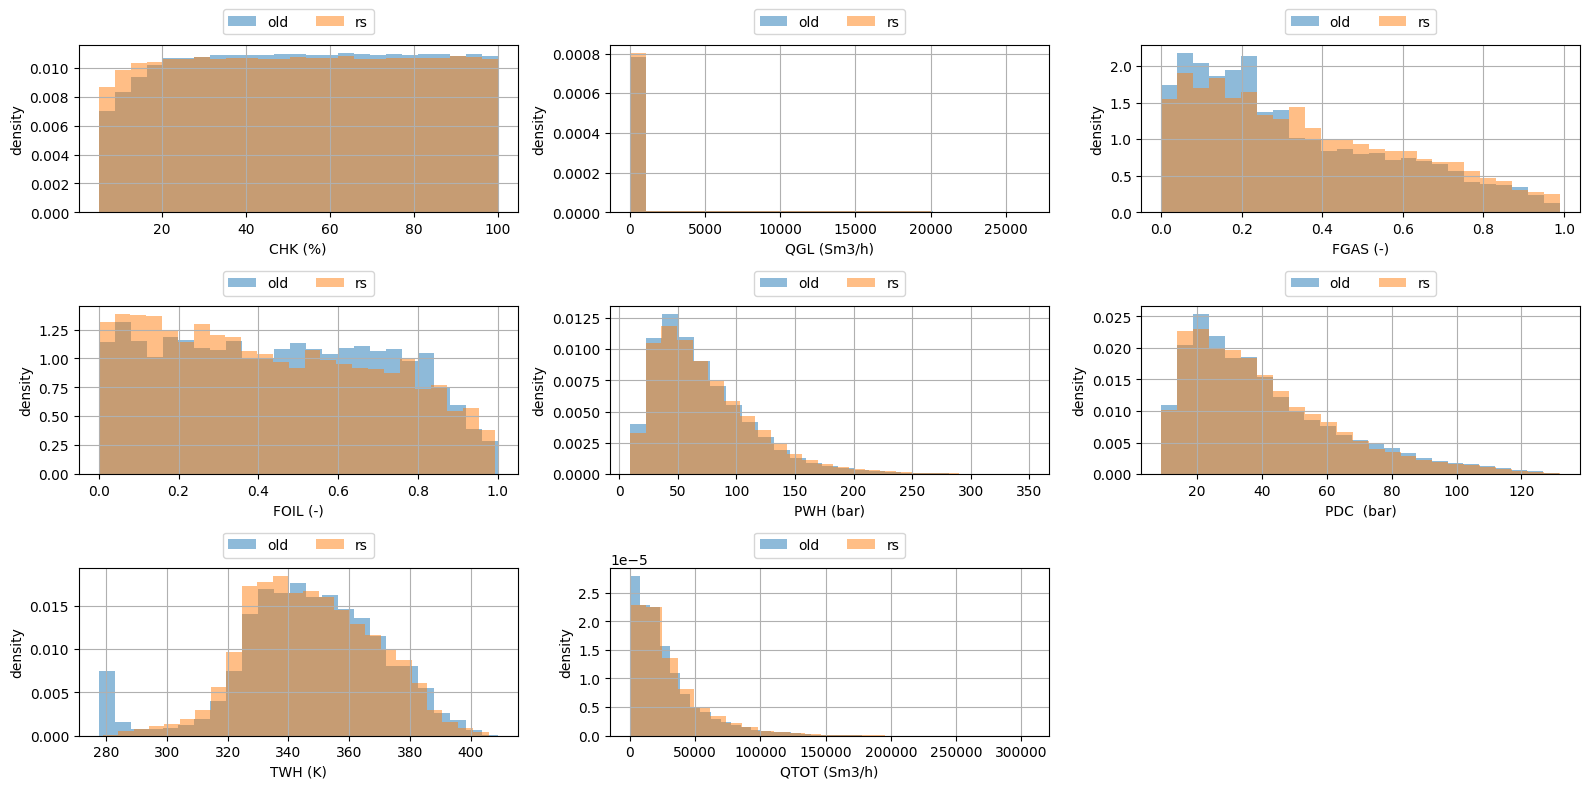

highest: if 1 sol, then include it. if 2 sol, take solution_number 1


<Figure size 640x480 with 0 Axes>

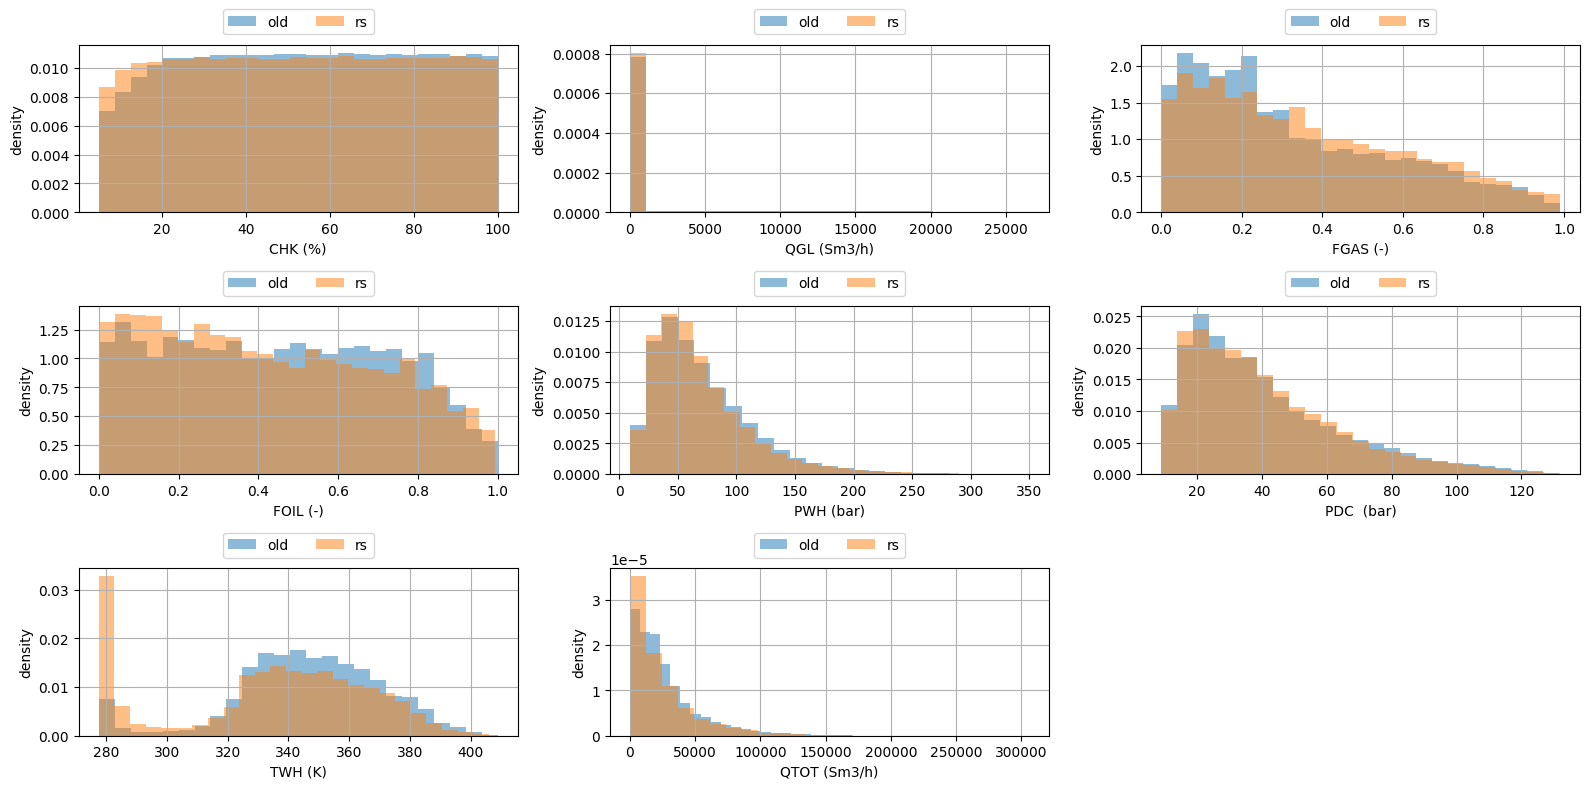

The lowest pbh solutions found, but excludes all cases were only one solution was found


<Figure size 640x480 with 0 Axes>

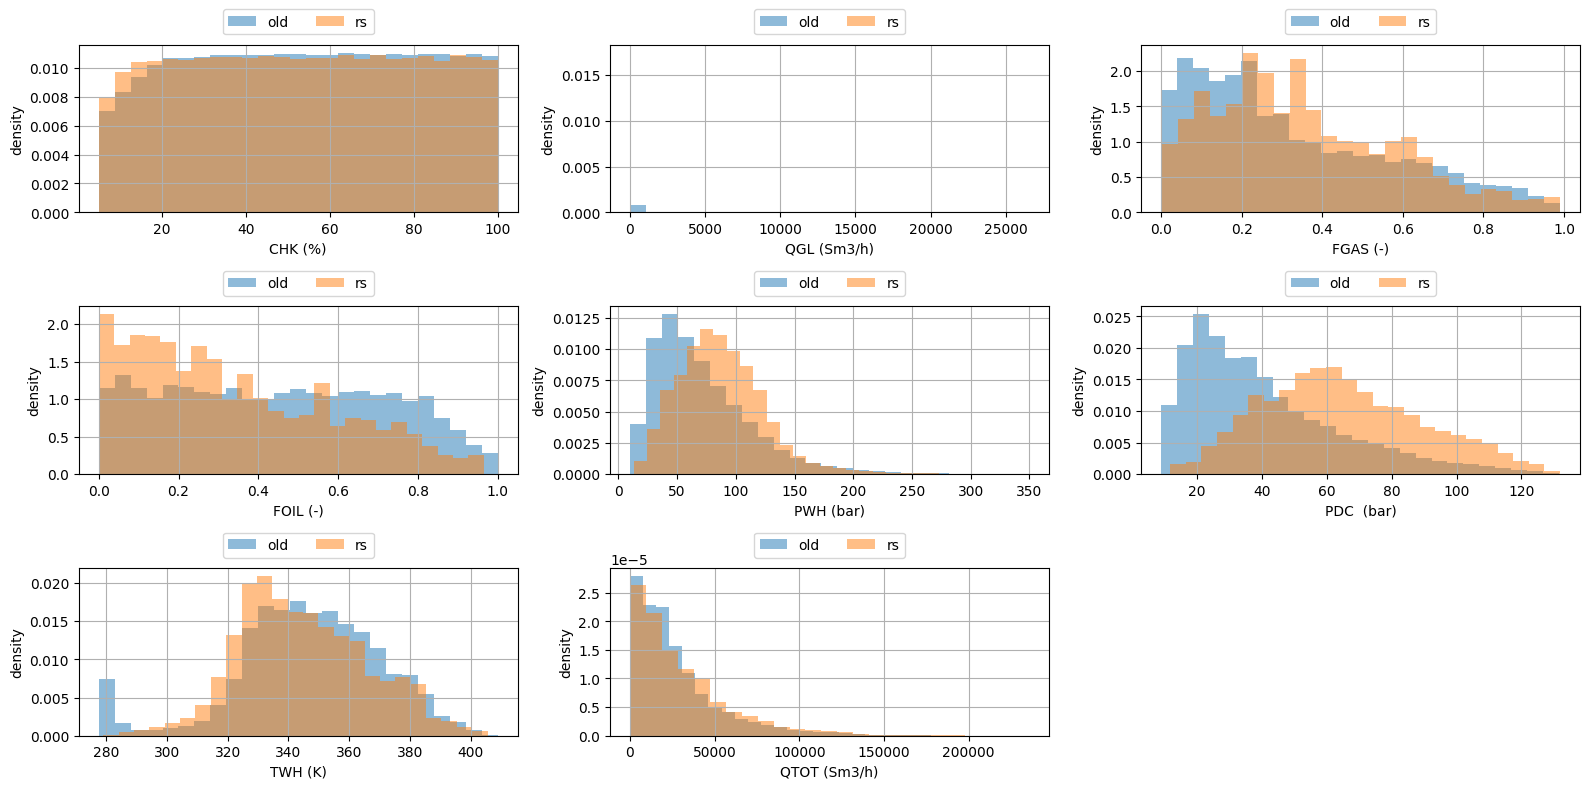

The highest pbh solutions found, but excludes all cases were only one solution was found


<Figure size 640x480 with 0 Axes>

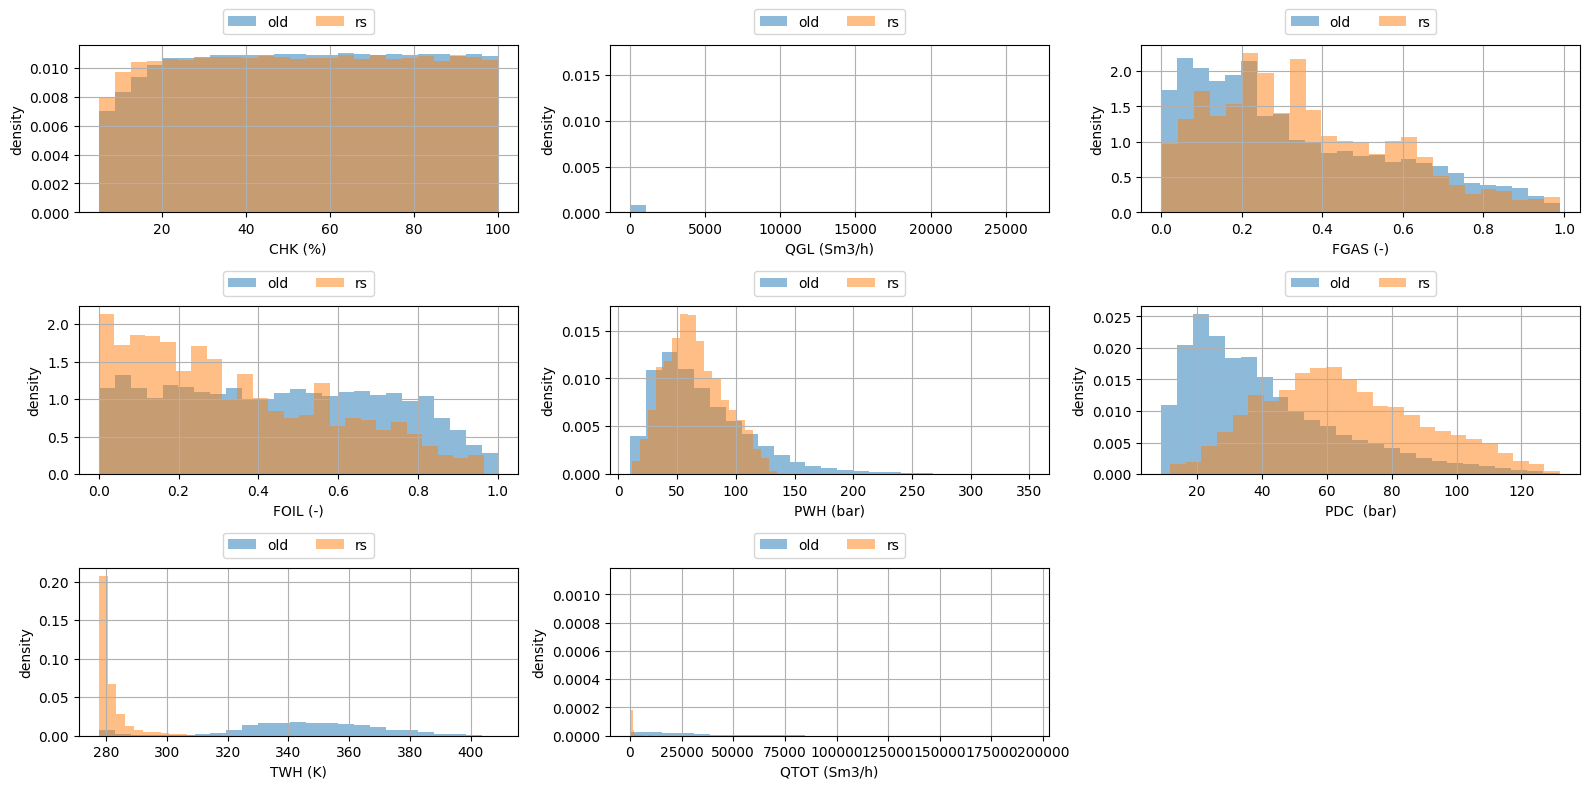

In [8]:
print("---------------- sol -------------------")
print("lowest: if 1 sol, then include it. if 2 sol, take solution_number 0")
compare_distributions(df_sol, df_sol_rs_lowest, filename="manywells_sol_compare_distributions_lowest_PBH")
print("highest: if 1 sol, then include it. if 2 sol, take solution_number 1")
compare_distributions(df_sol, df_sol_rs_highest, filename="manywells_sol_compare_distributions_highest_PBH")
print("The lowest pbh solutions found, but excludes all cases were only one solution was found")
compare_distributions(df_sol, df_sol_rs_lowest_if_2, filename="manywells_sol_compare_distributions_lowest_PBH_if_2_sols")
print("The highest pbh solutions found, but excludes all cases were only one solution was found")
compare_distributions(df_sol, df_sol_rs_highest_if_2, filename="manywells_sol_compare_distributions_highest_PBH_if_2_sols")


Then, I generated with the `scripts/data_generation/open_loop_nonstationary/generate_open_loop_nonstationary_well_data_rust_simulator.py` script.

In [9]:
dataset_name_nsol_rs = "manywells-nsol_rs"
df_nsol_rs = pd.read_csv(f"data/{dataset_name_nsol_rs}/{dataset_name_nsol_rs}-1.csv")
config_nsol_rs = pd.read_csv(f"data/{dataset_name_nsol_rs}/{dataset_name_nsol_rs}-1_config.csv")

In [10]:
df_nsol_rs_lowest = df_nsol_rs[df_nsol_rs['solution_number'] == 0] # lower pbh
idx = df_nsol_rs.groupby(['ID', 'sample_id'])['solution_number'].idxmax()
df_nsol_rs_highest = df_nsol_rs.loc[idx] # max solution number. this gives only the highest pbh solution found (and includes those were only 1 sol were found)


# groups where more than one solution exists
grp = df_nsol_rs.groupby(['ID', 'sample_id'])['solution_number']
counts = grp.transform('size')

df_multi = df_nsol_rs[counts > 1]

idx_low = df_multi.groupby(['ID', 'sample_id'])['solution_number'].idxmin()
df_nsol_rs_lowest_if_2 = df_multi.loc[idx_low]  # lowest pbh, only when >=2 solutions


df_nsol_rs_highest_if_2 = df_nsol_rs[df_nsol_rs['solution_number'] == 1] # higher pbh (but might be problematic if only 1 sol were found)


---------------- nsol -------------------
lowest: if 1 sol, then include it. if 2 sol, take solution_number 0


<Figure size 640x480 with 0 Axes>

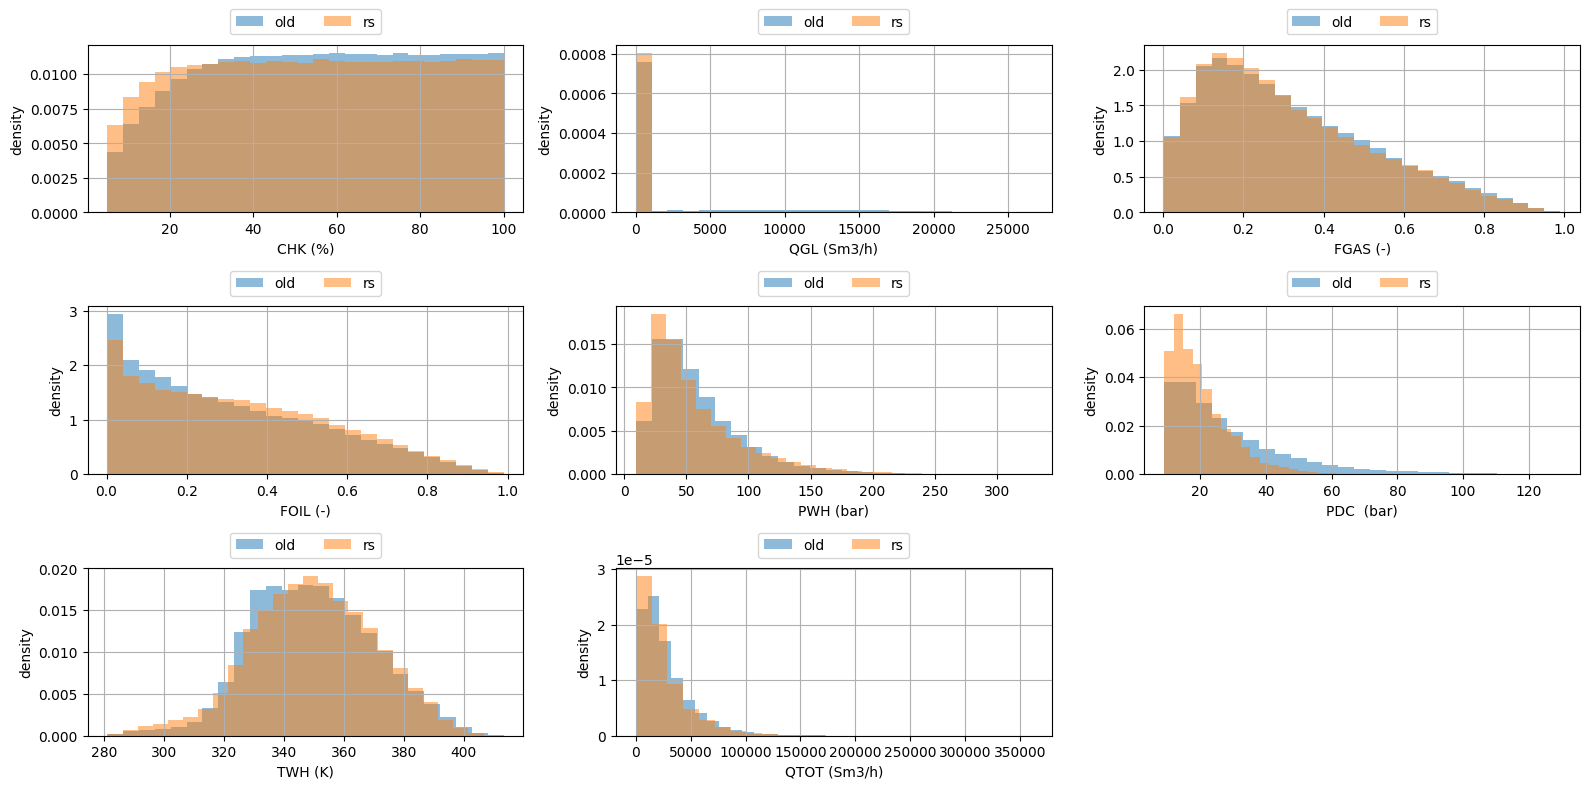

highest: if 1 sol, then include it. if 2 sol, take solution_number 1


<Figure size 640x480 with 0 Axes>

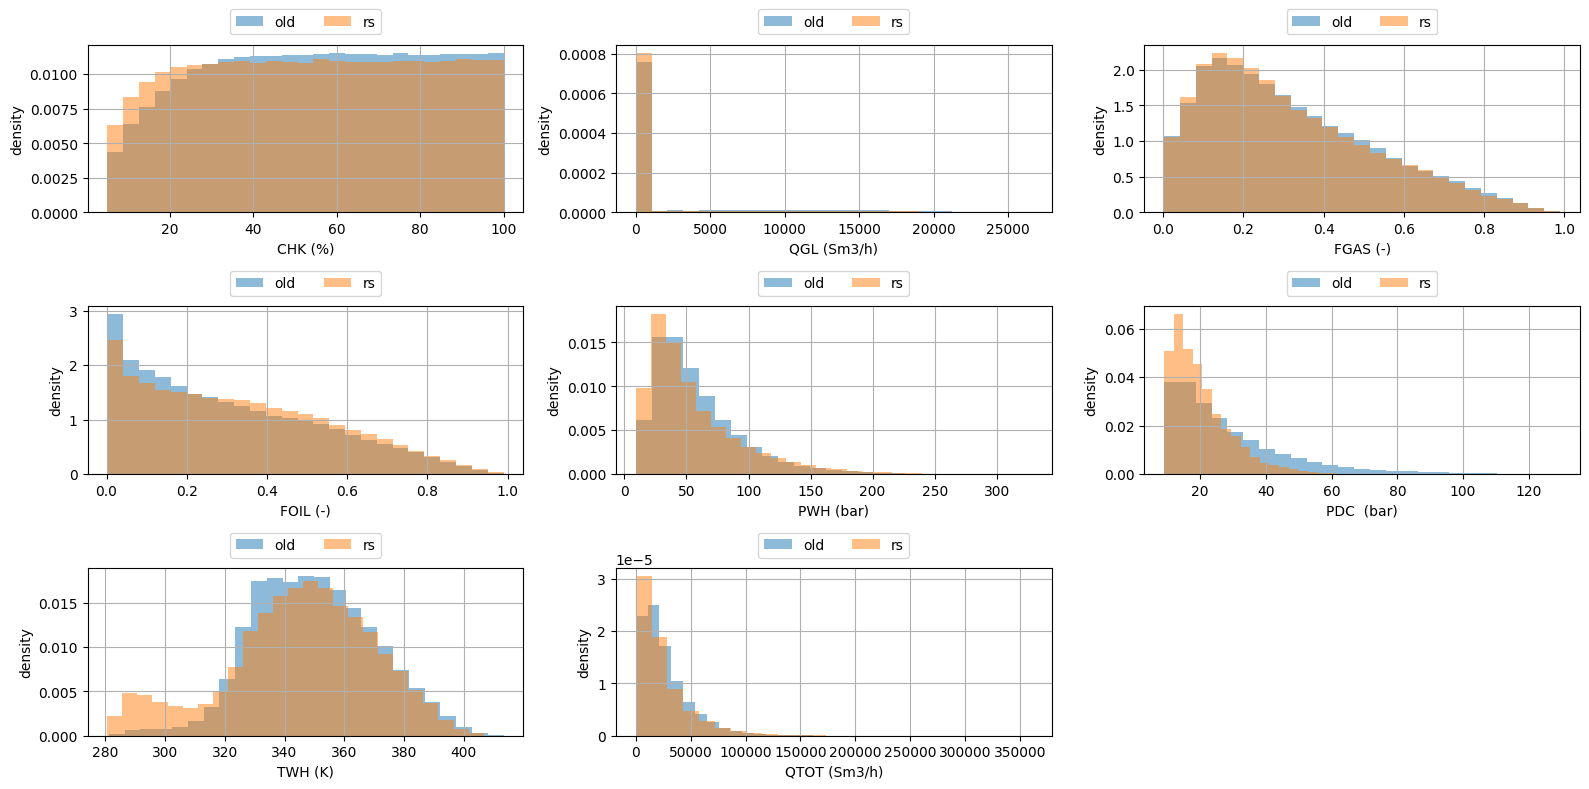

lowest, but excludes all cases were only one solution was found


<Figure size 640x480 with 0 Axes>

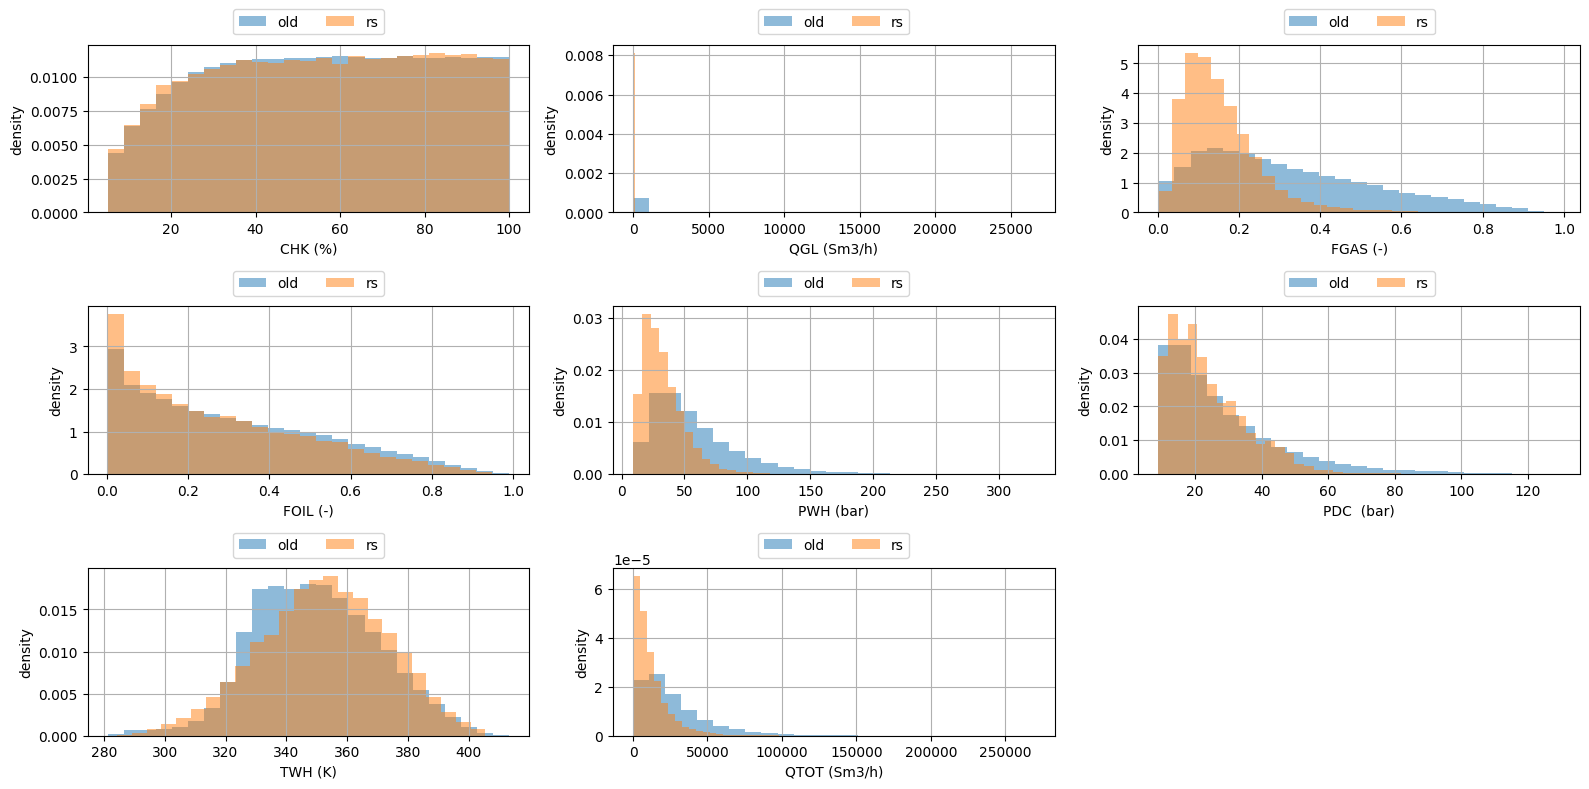

highest, but excludes all cases were only one solution was found


<Figure size 640x480 with 0 Axes>

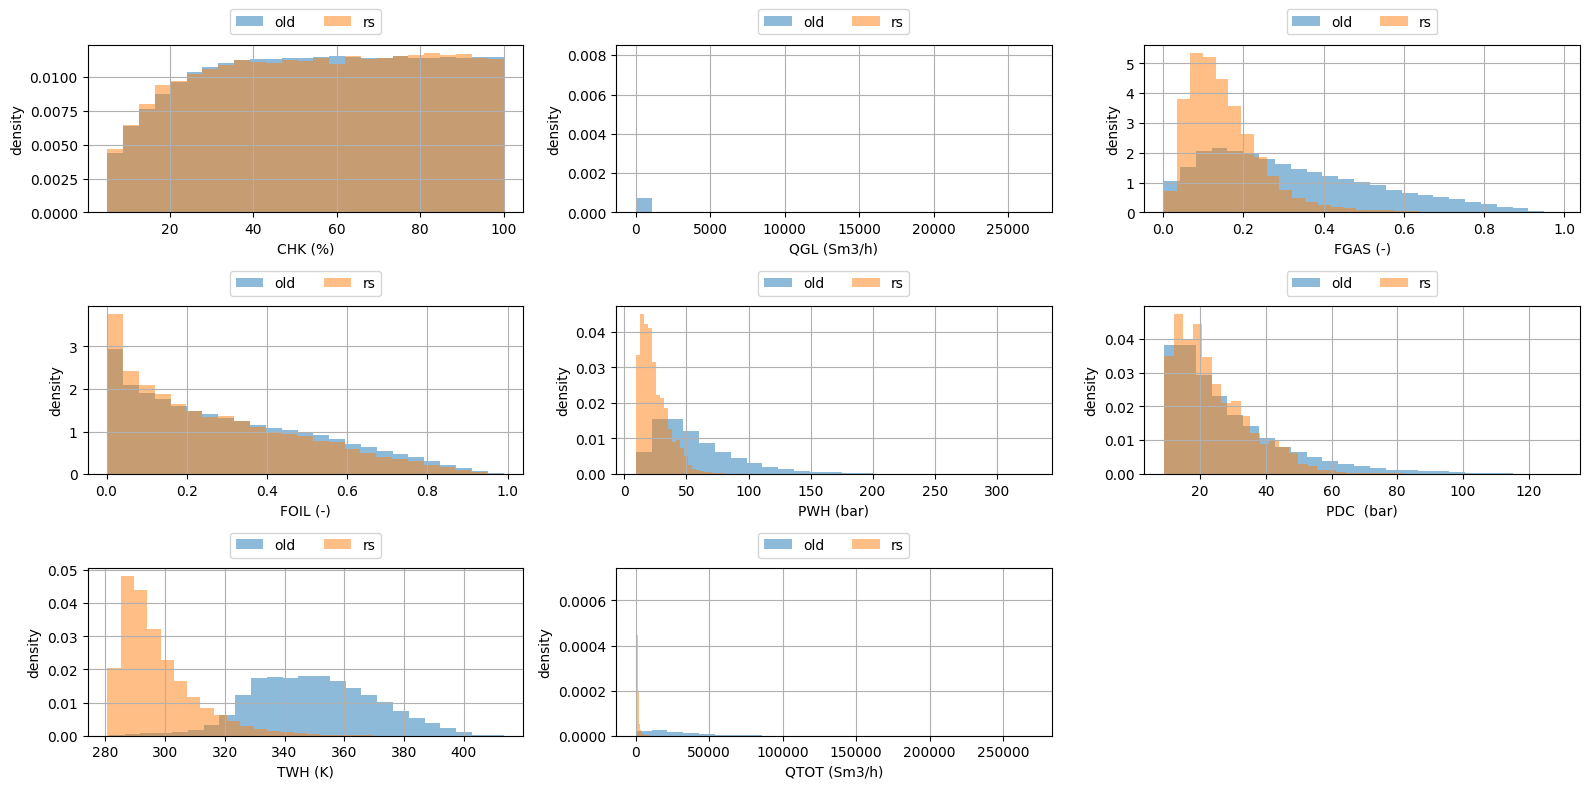

In [11]:
print("---------------- nsol -------------------")
print("lowest: if 1 sol, then include it. if 2 sol, take solution_number 0")
compare_distributions(df_nsol, df_nsol_rs_lowest, filename="manywells_nsol_compare_distributions_lowest_PBH")
print("highest: if 1 sol, then include it. if 2 sol, take solution_number 1")
compare_distributions(df_nsol, df_nsol_rs_highest, filename="manywells_nsol_compare_distributions_highest_PBH")
print("lowest, but excludes all cases were only one solution was found")
compare_distributions(df_nsol, df_nsol_rs_lowest_if_2, filename="manywells_nsol_compare_distributions_lowest_PBH_if_2_sols")
print("highest, but excludes all cases were only one solution was found")
compare_distributions(df_nsol, df_nsol_rs_highest_if_2, filename="manywells_nsol_compare_distributions_highest_PBH_if_2_sols")

# Convergence tests

Comparing the resulting values at the well head (z = L) for a random sample of well_ids over a range of discretization grids.

In [12]:
convergence_results = run_convergence(config, well_ids=random.sample(range(0, 2000), 5), n_cells_list=[50, 100, 150])


Well 246: sweeping N in [50, 100, 150] ...
Well 237: sweeping N in [50, 100, 150] ...
Well 1254: sweeping N in [50, 100, 150] ...
Well 1385: sweeping N in [50, 100, 150] ...
Well 289: sweeping N in [50, 100, 150] ...


<Axes: title={'center': 'Convergence of v_g (Rust vs. old simulator)'}, xlabel='N (number of cells)', ylabel='|v_g_rust - v_g_old| at z = L'>

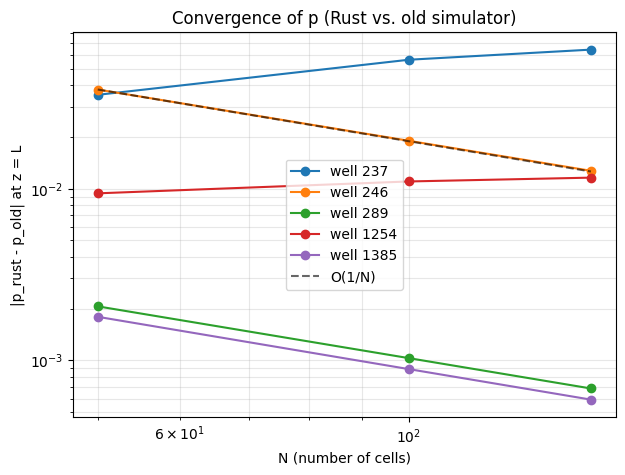

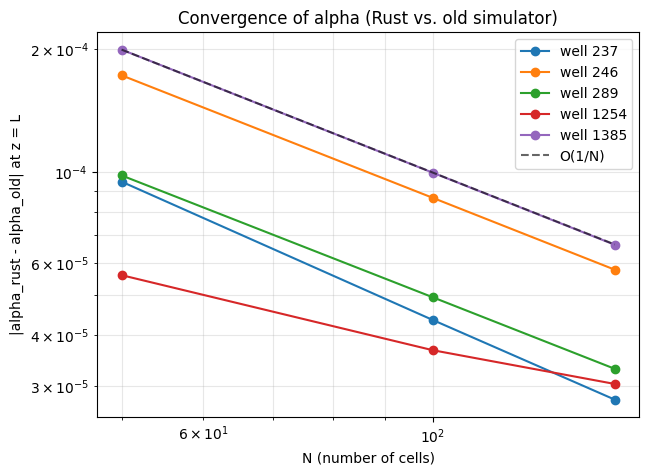

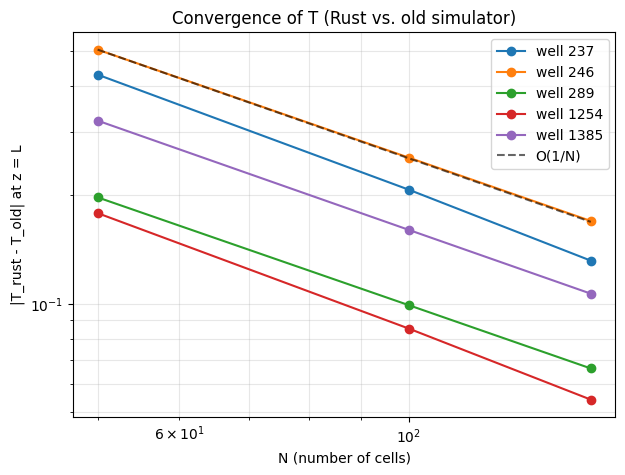

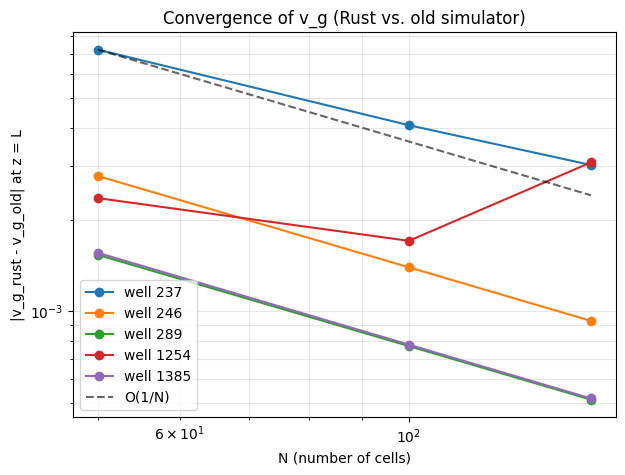

In [13]:
plot_convergence(convergence_results, variable='p')       # or 'alpha', 'T', etc.
plot_convergence(convergence_results, variable='alpha')       # or 'alpha', 'T', etc.
plot_convergence(convergence_results, variable='T')       # or 'alpha', 'T', etc.
plot_convergence(convergence_results, variable='v_g')       # or 'alpha', 'T', etc.

Use the `compare_operating_point` to compare the solution evolution over the entire well. In the cases where the rust simulator produces two solutions it plots both. The stars mark features found in the dataset.

Well 237, row 0, CHK=0.2257
             dataset   old (Ipopt) new (rust) #0 new (rust) #1
PBH       387.297827    381.758429    408.773303    381.758341
PWH       161.231092    157.288705     42.077617    157.330264
TBH       411.440636    411.440636    411.440636    411.440636
TWH       348.574472    347.797237    277.522173    348.024699
WGL              0.0           0.0           0.0           0.0
WGAS        4.596525      4.506349      0.018116      4.506364
WLIQ       11.733656     11.503462      0.046245     11.503499
WTOT        16.33018     16.009812      0.064361     16.009862
QGL              0.0           0.0           0.0           0.0
QGAS    21709.744869  21283.838824     85.562439  21283.905849
QLIQ       44.652776     43.776769      0.175986     43.776907
QTOT    21754.397645  21327.615593     85.738424  21327.682755
FGAS        0.281474      0.281474      0.281474      0.281474
CHOKED          True          True         False          True
FRBH      slug-churn    slu

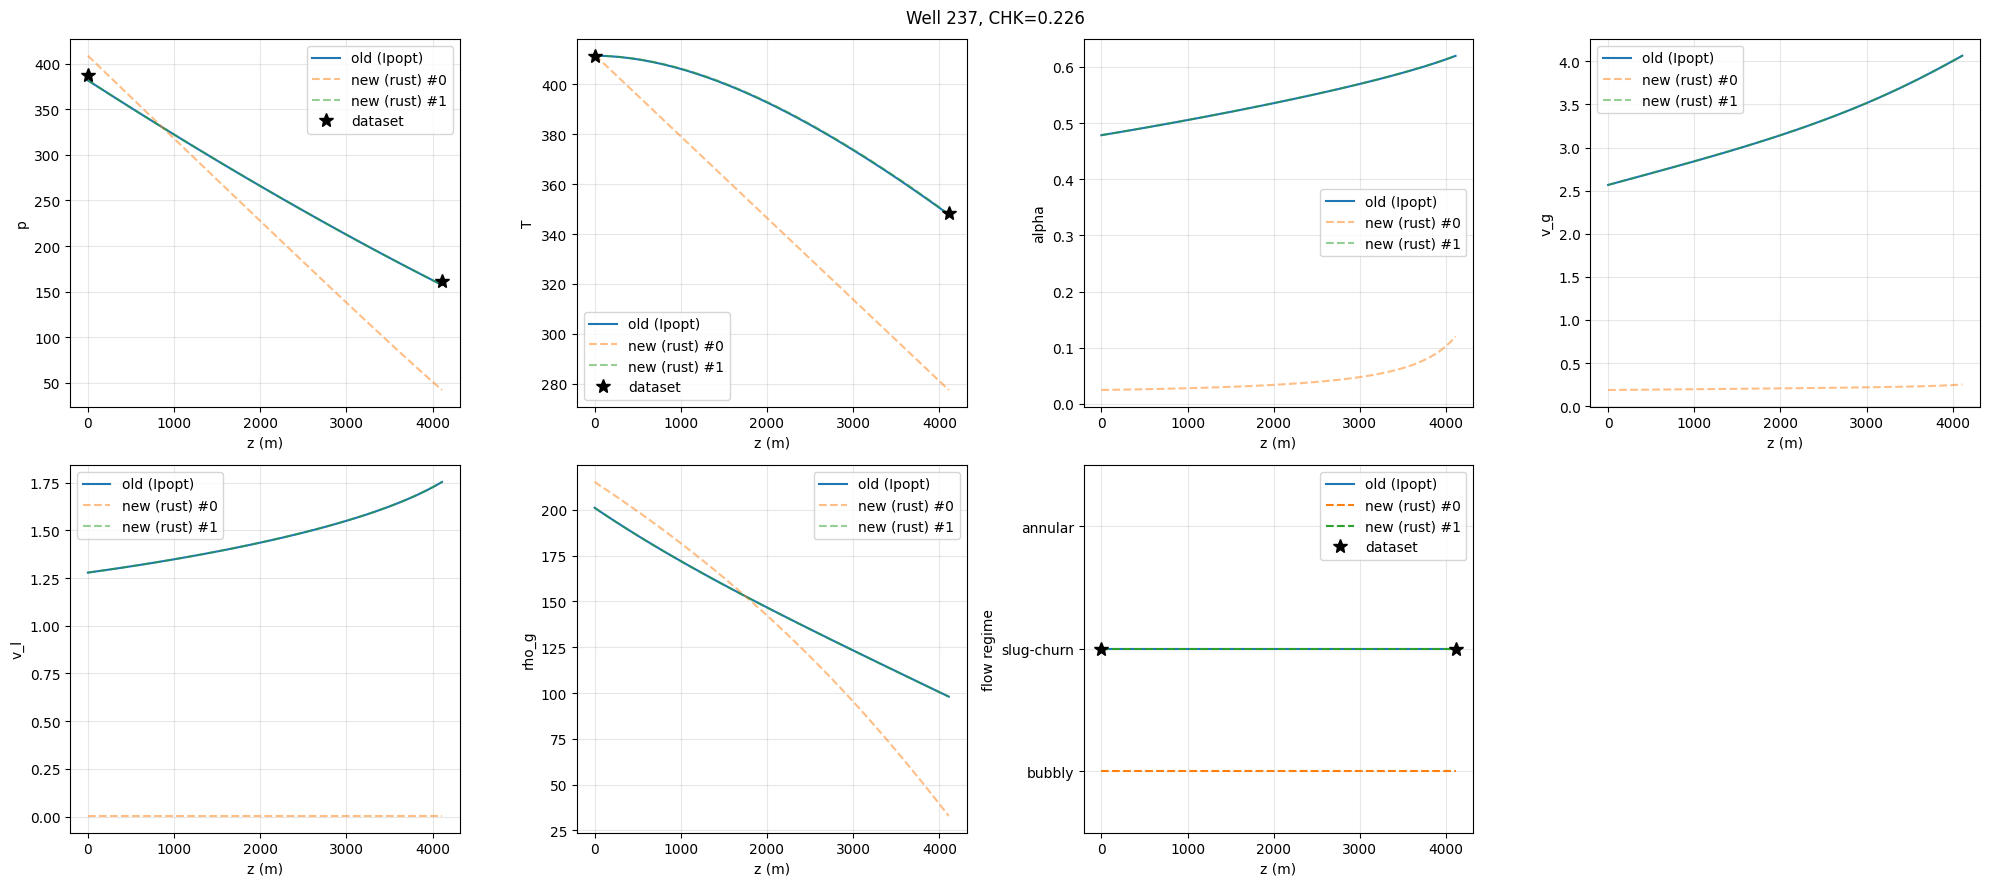

In [14]:
compare_operating_point(well_id=237, df_config=config, df_data=df)
print()

# Plot residual

The rust solver uses a shooting method on the initial bottomhole pressure $p(z=0)$. `plot_residual` plots the "error" in satisfying the choke model for each given $p(z=0) \in (p_\text{min}, p_\text{max})$.
The original simulator made an initial guess that 5% of the total pressure drop occurs at the inflow. This guess is marked in the plot.
When the simulator propagates a clamped solution ( to the top in an attempt to make the residual function smoother I mark this as "shady"
When the simulator fails I mark it as infeasible. 

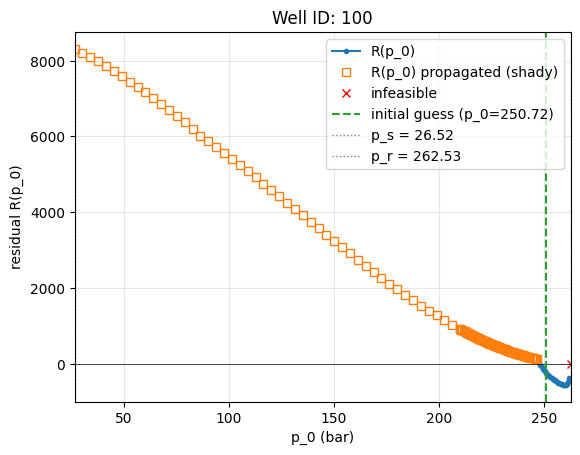

In [21]:
for WELL_ID in [100,]:
    wp, bc = load_well_config(WELL_ID, config)
    s = sim_rs.SSDFSimulator(wp, bc)
    
    fig, ax = plt.subplots()
    p0s = np.concatenate([np.linspace(bc.p_s, 0.8 * bc.p_r, 50),
                              np.linspace(0.8 * bc.p_r, bc.p_r, 100)])
    p0s, residuals, _ = plot_residual(s, p_min=bc.p_s, p_max=bc.p_r, n_points=200, p0s=p0s, ax = ax)
    ax.set(title=f"Well ID: {WELL_ID}")
    plt.show()

# Benchmarking

The function `run_benchmark` can be used to measure solution times and accuracy. Running it without setting max_wells will run it on all wells (this takes time...)

In [ ]:
# bench_results = run_benchmark(sim_names=["rust", "simulator"], max_wells=10)
bench_results = run_benchmark(sim_names=["rust", "simulator"], max_wells=100)

In [5]:
bench_results[2]['rust']['failed_ids']

[13]

# Just playing around

The rest of this notebook is just me playing around with the simulators

In [19]:
dataset_name = "manywells-sol"

df = pd.read_csv(f"data/{dataset_name}/{dataset_name}-1.zip", compression="zip")
config = pd.read_csv(f"data/{dataset_name}/{dataset_name}-1_config.zip", compression="zip")
wp, bc = load_well_config(977, config)

simulator = sim.SSDFSimulator(wp, bc)
solutions = simulator.simulate()

if type(solutions[0]) == list:
    print("number of solutions:", len(solutions))
    
    if len(solutions) == 2:
        x = solutions[0]
        x = simulator.solution_as_df(x)
        print(x)
        x = solutions[1]
        x = simulator.solution_as_df(x)
        print(x)
    elif len(solutions) == 1:
        x = solutions[0]
        x = simulator.solution_as_df(x)
        print(x)
else:
    x = simulator.solution_as_df(solutions)
    print(x)

               z           p       v_g       v_l     alpha       rho_g  \
0       0.000000  169.000393  4.011708  2.119382  0.543637  116.011479   
1      21.132954  167.791793  4.029709  2.126196  0.545100  115.183352   
2      42.265907  166.585823  4.047869  2.133083  0.546568  114.358514   
3      63.398861  165.382485  4.066188  2.140043  0.548043  113.536925   
4      84.531814  164.181781  4.084670  2.147080  0.549525  112.718544   
..           ...         ...       ...       ...       ...         ...   
96   2028.763537   73.916197  5.800573  5.249613  0.815757   53.469739   
97   2049.896490   73.242214  5.836496  5.295818  0.817364   53.036131   
98   2071.029444   72.570915  5.873042  5.342229  0.818951   52.603985   
99   2092.162397   71.902235  5.910219  5.388879  0.820518   52.173246   
100  2113.295351   71.236112  5.948033  5.435796  0.822067   51.743861   

          rho_l           T flow-regime  
0    989.499088  351.548861  slug-churn  
1    989.499088  351.544205

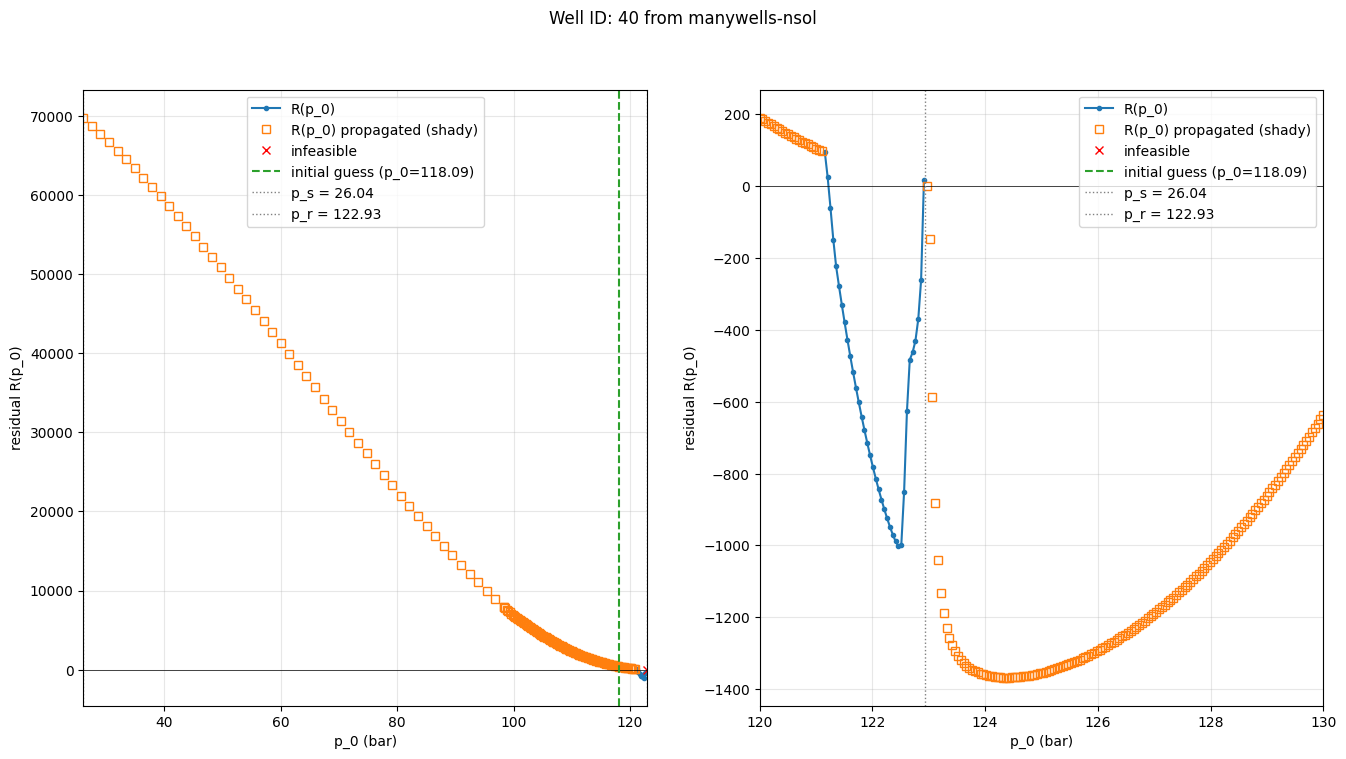

In [3]:
for WELL_ID in [40,]:
    wp, bc = load_well_config(WELL_ID, config)
    s = sim_rs.SSDFSimulator(wp, bc)
    
    fig, axs = plt.subplots(1, 2, figsize=(16, 8))
    p0s = np.concatenate([np.linspace(bc.p_s, 0.8 * bc.p_r, 50),
                              np.linspace(0.8 * bc.p_r, bc.p_r, 100)])
    p0s, residuals, _ = plot_residual(s, p_min=bc.p_s, p_max=bc.p_r, n_points=200, p0s=p0s, ax = axs[0])
    p0s, residuals, _ = plot_residual(s, p_min=120, p_max=130, n_points=200, ax = axs[1])
    fig.suptitle(f"Well ID: {WELL_ID} from {dataset_name}")
    plt.show()

In [26]:
wp, bc = load_well_config(977, config)
s = sim_rs.SSDFSimulator(wp, bc)
solutions = s.simulate()
for solution in solutions:
    print(s.solution_as_df(solution))

s = sim.SSDFSimulator(wp, bc)
solution = s.simulate()
print(s.solution_as_df(solution))

               z           p       v_g       v_l     alpha       rho_g  \
0       0.000000  208.022441  0.429155  0.097152  0.293135  142.798431   
1      21.132954  206.488292  0.430367  0.097333  0.294455  141.758223   
2      42.265907  204.957027  0.431576  0.097512  0.295746  140.743999   
3      63.398861  203.428593  0.432783  0.097687  0.297012  139.753181   
4      84.531814  201.902943  0.433990  0.097860  0.298256  138.783443   
..           ...         ...       ...       ...       ...         ...   
96   2028.763537   74.266742  0.665265  0.121479  0.434694   62.119453   
97   2049.896490   73.054105  0.671368  0.121926  0.436763   61.263108   
98   2071.029444   71.846217  0.677656  0.122379  0.438848   60.406319   
99   2092.162397   70.643114  0.684136  0.122838  0.440949   59.549114   
100  2113.295351   69.444835  0.690815  0.123306  0.443066   58.691521   

          rho_l           T flow-regime  
0    989.499088  351.548861      bubbly  
1    989.499088  351.516824

In [6]:
bench_results = run_benchmark(sim_names=["rust"], max_wells=100)


Simulator benchmark: rust
Data root: /home/oskar/manywells/data
Max wells per config: 100

/home/oskar/manywells/data/manywells-nscl/manywells-nscl-1_config.zip
  simulator     wells  success   fail   total(s)   mean(s)  median(s)    max(s)
  rust            100      100      0      0.793    0.0079     0.0080    0.0168

/home/oskar/manywells/data/manywells-nsol/manywells-nsol-1_config.zip
  simulator     wells  success   fail   total(s)   mean(s)  median(s)    max(s)
  rust            100       99      1      0.851    0.0085     0.0082    0.0465

/home/oskar/manywells/data/manywells-sol/manywells-sol-1_config.zip
  simulator     wells  success   fail   total(s)   mean(s)  median(s)    max(s)
  rust            100      100      0      0.508    0.0051     0.0049    0.0104

Overall
  simulator     wells  success   fail   total(s)  mean/well(s)  speedup
  rust            300      299      1      2.153        0.0072     1.0x


In [8]:
bench_results[1]

{'rust': {'n_wells': 100,
  'n_success': 97,
  'n_fail': 3,
  'failed_ids': [23, 40, 64],
  'total_time': 0.7765839386265725,
  'mean_time': 0.007765839386265725,
  'median_time': 0.007281098456587642,
  'min_time': 0.0029391139978542924,
  'max_time': 0.035135607002303004,
  'std_time': 0.004031216077838446}}